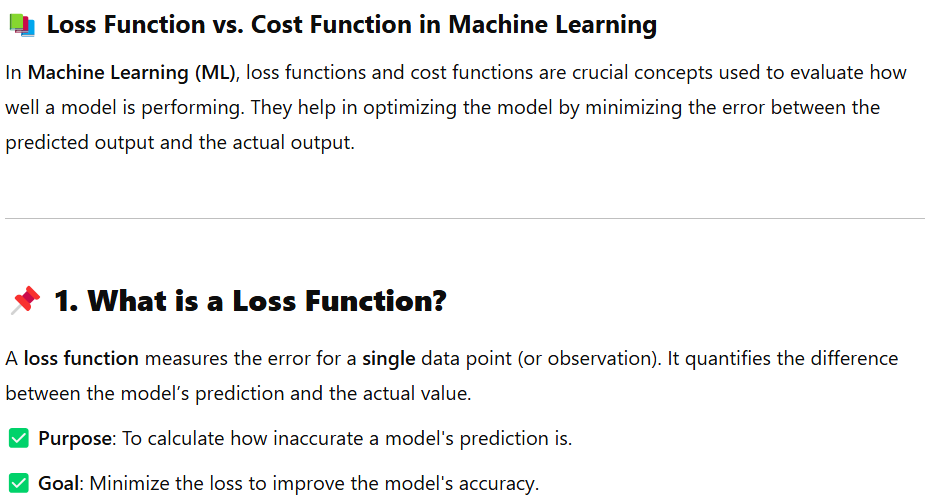

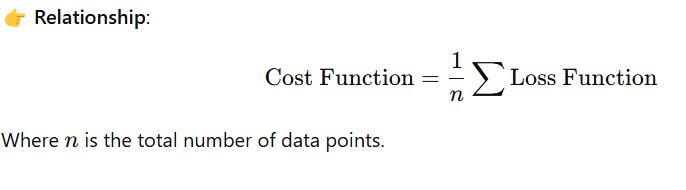

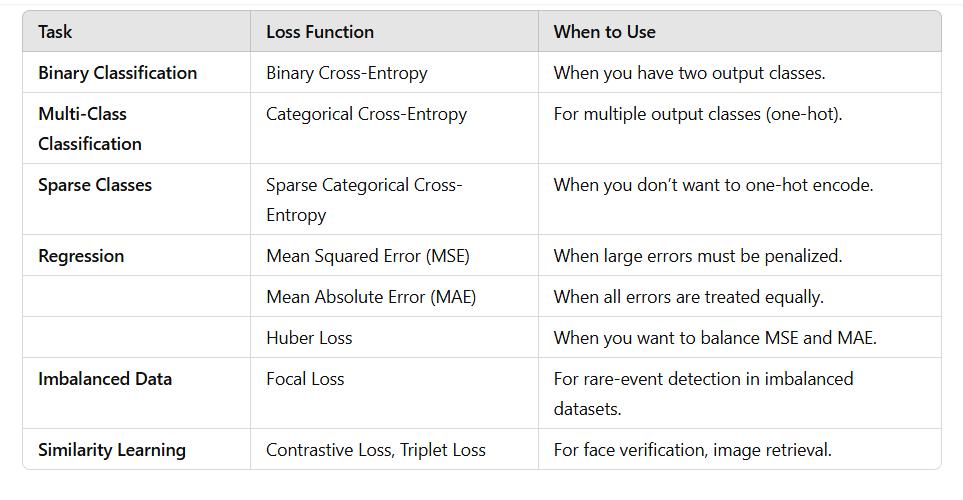

In [1]:
import numpy as np

# Mean Squared Error (MSE)
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Mean Absolute Error (MAE)
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Huber Loss
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta
    squared_loss = 0.5 * error ** 2
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

# Binary Cross-Entropy (BCE)
def binary_cross_entropy(y_true, y_pred, epsilon=1e-15):
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Avoid log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Multi-Class Cross-Entropy
def cross_entropy(y_true, y_pred, epsilon=1e-15):
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Avoid log(0)
    return -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]

# Hinge Loss
def hinge_loss(y_true, y_pred):
    return np.mean(np.maximum(0, 1 - y_true * y_pred))

# Example Usage
if __name__ == "__main__":
    # Regression Example
    y_true_reg = np.array([3.0, -0.5, 2.0, 7.0])
    y_pred_reg = np.array([2.5, 0.0, 2.0, 8.0])
    print("MSE:", mse(y_true_reg, y_pred_reg))
    print("MAE:", mae(y_true_reg, y_pred_reg))
    print("Huber Loss:", huber_loss(y_true_reg, y_pred_reg))

    # Binary Classification Example
    y_true_bin = np.array([1, 0, 1, 0])
    y_pred_bin = np.array([0.9, 0.1, 0.8, 0.3])
    print("Binary Cross-Entropy:", binary_cross_entropy(y_true_bin, y_pred_bin))

    # Multi-Class Classification Example
    y_true_multi = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])  # One-hot encoded
    y_pred_multi = np.array([[0.7, 0.2, 0.1], [0.1, 0.8, 0.1], [0.2, 0.3, 0.5]])
    print("Multi-Class Cross-Entropy:", cross_entropy(y_true_multi, y_pred_multi))

    # Hinge Loss Example
    y_true_hinge = np.array([1, -1, 1, -1])  # Labels must be -1 or 1
    y_pred_hinge = np.array([0.9, -0.5, 0.7, -0.2])
    print("Hinge Loss:", hinge_loss(y_true_hinge, y_pred_hinge))

MSE: 0.375
MAE: 0.5
Huber Loss: 0.1875
Binary Cross-Entropy: 0.19763488164214868
Multi-Class Cross-Entropy: 0.4243218919376292
Hinge Loss: 0.42500000000000004


A cost function measures the error between predictions and true values. The goal is to minimize it to improve the model's performance.


Convex functions have a single global minimum, making optimization straightforward.

Non-convex functions may have multiple local minima, requiring careful optimization to avoid suboptimal solutions.

Gradient Descent adjusts model parameters iteratively to find the minimum. For non-convex functions, algorithms like Adam or momentum help escape local minima.